# NB03 — Multi-Type Chunking Pipeline

This notebook builds a unified chunking pipeline that handles all content families identified in NB01,
using `corpus_filter.py` as the file selection entry point and LangChain splitters for each content type.

**Context:**
- NB01 identified 8 content families across 25 projects (~3,800 retained files).
- NB02 tested chunking on Markdown docs only (139 files) — Manual vs LangChain.
- This notebook extends the pipeline to JS, Vue SFC, JSON, and tests a mixed index.

**Sections:**
1. Configuration and corpus loading
2. Content-type-specific splitters
3. Unified chunk assembly and statistics
4. Embedding and Qdrant ingestion
5. Evaluation (extended question set)
6. Analysis and conclusions

---
## 1. Configuration and Corpus Loading

In [17]:
import json
import re
import sys
from pathlib import Path
from collections import defaultdict

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from dotenv import load_dotenv

from langchain_text_splitters import (
    RecursiveCharacterTextSplitter,
    MarkdownHeaderTextSplitter,
    MarkdownTextSplitter,
)
from langchain_text_splitters import Language

load_dotenv()

# Allow imports from scripts/ and src/
ROOT_DIR = Path("..").resolve()
sys.path.insert(0, str(ROOT_DIR / "scripts"))
sys.path.insert(0, str(ROOT_DIR / "src"))
from corpus_filter import scan_corpus

sns.set_theme(style="whitegrid", palette="muted")
matplotlib.rcParams["figure.dpi"] = 120

print("All imports OK")

All imports OK


In [18]:
# ── Paths and constants ──
KDK_DIR = ROOT_DIR / "data" / "kdk"
OUTPUT_DIR = ROOT_DIR / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

QDRANT_URL = "http://localhost:6333"
EMBEDDING_MODEL = "nomic-ai/nomic-embed-text-v1.5"

# Chunk size parameters per content type
CHUNK_PARAMS = {
    "markdown":   {"chunk_size": 1000, "chunk_overlap": 200},
    "javascript": {"chunk_size": 1500, "chunk_overlap": 200},
    "vue":        {"chunk_size": 1500, "chunk_overlap": 200},
    "json":       {"max_chunk_size": 800},
    "other":      {"chunk_size": 1000, "chunk_overlap": 200},
}

print(f"KDK dir: {KDK_DIR} (exists={KDK_DIR.exists()})")
print(f"Chunk parameters per type:")
for ctype, params in CHUNK_PARAMS.items():
    print(f"  {ctype:<12} {params}")

KDK dir: /home/kalisio/Documents/kalisio/knowledge/data/kdk (exists=True)
Chunk parameters per type:
  markdown     {'chunk_size': 1000, 'chunk_overlap': 200}
  javascript   {'chunk_size': 1500, 'chunk_overlap': 200}
  vue          {'chunk_size': 1500, 'chunk_overlap': 200}
  json         {'max_chunk_size': 800}
  other        {'chunk_size': 1000, 'chunk_overlap': 200}


In [19]:
# ── Scan corpus and classify files by content family ──
kdk_scan = scan_corpus(KDK_DIR)
print(kdk_scan.summary())
print()


def classify_file(rec) -> str:
    """Classify a FileRecord into a content family."""
    rel = rec.rel_path
    ext = rec.extension

    # Markdown documentation
    if ext == ".md" and rel.startswith("docs/"):
        return "documentation_markdown"

    # Vue Single File Components
    if ext == ".vue":
        return "vue_sfc"

    # JSON — distinguish schemas vs i18n
    if ext == ".json":
        if "schemas/" in rel or "schema" in Path(rel).stem.lower():
            return "json_schemas"
        if "i18n/" in rel or rel.endswith(".i18n.json"):
            return "json_i18n"
        return "json_other"

    # JavaScript — distinguish barrel files vs code
    if ext in (".js", ".mjs", ".cjs"):
        name = Path(rel).name
        if name == "index.js":
            return "barrel_index_js"
        return "code_js"

    # Other text
    if ext in (".yaml", ".yml", ".sh", ".html", ".ejs", ".css", ".scss"):
        return "other_text"

    return "uncategorized"


# Apply classification to all included files
family_map = defaultdict(list)
for rec in kdk_scan.included:
    family = classify_file(rec)
    family_map[family].append(rec)

# Distribution table
rows = []
for family, recs in sorted(family_map.items(), key=lambda x: -len(x[1])):
    total_size = sum(r.size for r in recs)
    est_tokens = total_size // 4  # rough estimate: 1 token ≈ 4 chars
    rows.append({
        "content_family": family,
        "files": len(recs),
        "total_size_kb": round(total_size / 1024, 1),
        "est_tokens": est_tokens,
    })

family_df = pd.DataFrame(rows)
print(family_df.to_string(index=False))
print(f"\nTotal included files: {len(kdk_scan.included)}")

Corpus filter — /home/kalisio/Documents/kalisio/knowledge/data/kdk
  Scanned:     970
  Included:    827
  Excluded:    143

Included by extension:
  .js            361 files      1.5 MB
  .vue           242 files    832.5 KB
  .md            141 files    503.3 KB
  .json           23 files      3.5 MB
  .mjs            18 files     55.4 KB
  .xml            16 files      2.7 MB
  .ejs             9 files      4.3 KB
  .cjs             6 files     13.2 KB
  .sh              4 files      4.2 KB
  .scss            2 files      2.3 KB
  .html            2 files      3.7 KB
  .css             1 files     105.0 B
  .skip            1 files    1015.0 B
  .txt             1 files     71.3 KB

Included by zone:
  core           305 files    918.8 KB
  map            238 files      1.3 MB
  docs           158 files      3.1 MB
  test            45 files      3.6 MB
  extras          36 files     91.6 KB
  vite            27 files     67.0 KB
  (root)          14 files      4.2 KB
  scripts     

In [20]:
# ── Select families to chunk (exclude: barrel files, uncategorized, json_other) ──
FAMILIES_TO_CHUNK = {
    "documentation_markdown",
    "code_js",
    "vue_sfc",
    "json_schemas",
    "json_i18n",
    "other_text",
}

files_to_chunk = {
    family: [rec for rec in recs]
    for family, recs in family_map.items()
    if family in FAMILIES_TO_CHUNK
}

print("Families selected for chunking:")
for family, recs in sorted(files_to_chunk.items(), key=lambda x: -len(x[1])):
    print(f"  {family:<25} {len(recs):>4} files")

excluded_families = set(family_map.keys()) - FAMILIES_TO_CHUNK
print(f"\nExcluded families: {', '.join(sorted(excluded_families))}")

Families selected for chunking:
  code_js                    339 files
  vue_sfc                    242 files
  documentation_markdown     139 files
  other_text                  18 files
  json_schemas                 9 files
  json_i18n                    4 files

Excluded families: barrel_index_js, json_other, uncategorized


---
## 2. Content-Type-Specific Splitters

Each content family gets a dedicated LangChain splitter configured for its structure.

### 2a. Markdown — RecursiveCharacterTextSplitter

Reuses the same approach as `scripts/chunk_md_langchain.py` (validated in NB02):

1. Use `RecursiveCharacterTextSplitter` with heading-aware separators `["\n## ", "\n### ", "\n\n", "\n", " "]`.
2. `chunk_size=1000`, `chunk_overlap=200` (same parameters as NB02's LangChain strategy).
3. Extract `doc_title` from the first `# ` heading line.
4. Attach metadata: `source`, `doc_title`, `section_title`, `content_type=markdown`, `zone`.

In [21]:
# ── 2a. Markdown chunking (same approach as chunk_md_langchain.py) ──

DOCS_DIR = KDK_DIR / "docs"

md_splitter = RecursiveCharacterTextSplitter(
    chunk_size=CHUNK_PARAMS["markdown"]["chunk_size"],
    chunk_overlap=CHUNK_PARAMS["markdown"]["chunk_overlap"],
    separators=["\n## ", "\n### ", "\n\n", "\n", " "],
)


def get_doc_title(lines: list[str], fallback: str) -> str:
    for line in lines:
        if line.startswith("# ") and not line.startswith("## "):
            return line[2:].strip()
    return fallback


def chunk_markdown_files(file_records: list) -> list[dict]:
    """Chunk markdown files using RecursiveCharacterTextSplitter."""
    chunks = []
    for rec in file_records:
        text = rec.path.read_text(encoding="utf-8")
        lines = text.splitlines()
        rel_path = str(rec.path.relative_to(DOCS_DIR))
        doc_title = get_doc_title(lines, rec.path.stem)

        docs = md_splitter.create_documents(
            texts=[text],
            metadatas=[{
                "source": rel_path,
                "doc_title": doc_title,
                "section_title": doc_title,
            }],
        )

        for i, doc in enumerate(docs):
            content = doc.page_content.strip()
            if not content:
                continue
            chunks.append({
                "text": content,
                "metadata": {
                    **dict(doc.metadata),
                    "content_type": "markdown",
                    "zone": rec.zone,
                    "chunk_index": i,
                    "char_count": len(content),
                },
            })
    return chunks


md_chunks = chunk_markdown_files(files_to_chunk.get("documentation_markdown", []))
md_lengths = [c["metadata"]["char_count"] for c in md_chunks]

print(f"Markdown chunks: {len(md_chunks)}")
print(f"  Mean size: {np.mean(md_lengths):.0f} chars")
print(f"  Median:    {np.median(md_lengths):.0f} chars")
print(f"  Min/Max:   {min(md_lengths)} / {max(md_lengths)} chars")
print(f"  < 50 chars: {sum(1 for l in md_lengths if l < 50)}")
print(f"  > 1000 chars: {sum(1 for l in md_lengths if l > 1000)}")

Markdown chunks: 873
  Mean size: 604 chars
  Median:    660 chars
  Min/Max:   3 / 999 chars
  < 50 chars: 45
  > 1000 chars: 0


### 2b. Markdown — MarkdownHeaderTextSplitter + MarkdownTextSplitter

NB02 tested `RecursiveCharacterTextSplitter` (RCT) with heading-aware separators on the 139 Markdown docs.
Here we test two **dedicated** LangChain Markdown splitters on the same corpus:

**Strategy B1 — MarkdownHeaderTextSplitter (metadata-aware)**:
- Splits on `#`, `##`, `###` headers and injects them as metadata fields (`h1`, `h2`, `h3`).
- Does **not** control chunk size — produces one chunk per section.
- To control size, we chain it with a secondary `RecursiveCharacterTextSplitter` (re-split oversized sections).
- This preserves header hierarchy in metadata, which could improve retrieval precision.

**Strategy B2 — MarkdownTextSplitter**:
- Subclass of `RecursiveCharacterTextSplitter` with Markdown-specific separators
  (`\n## `, `\n### `, `\n#### `, `\n\n`, `\n`, ` `, `""`).
- Controls `chunk_size` and `chunk_overlap` like RCT, but uses Markdown structure for split points.
- Simpler than B1 (no metadata injection), but more Markdown-aware than generic RCT.

**Comparison axes** (same as NB02):
- Chunk count, size distribution (mean, median, σ, tiny/oversized counts)
- Metadata richness (does the chunk carry its heading context?)
- Visual retrieval comparison on sample questions

In [22]:
# ── 2b. Strategy B1: MarkdownHeaderTextSplitter (chained with RCT for size control) ──

# Step 1: Split by headers → one chunk per section, headers become metadata
md_header_splitter = MarkdownHeaderTextSplitter(
    headers_to_split_on=[
        ("#", "h1"),
        ("##", "h2"),
        ("###", "h3"),
    ],
    strip_headers=False,  # keep headers in content for embedding context
)

# Step 2: Re-split oversized sections with RCT (same params as 2a for comparability)
md_resplit = RecursiveCharacterTextSplitter(
    chunk_size=CHUNK_PARAMS["markdown"]["chunk_size"],
    chunk_overlap=CHUNK_PARAMS["markdown"]["chunk_overlap"],
)


def chunk_md_header_splitter(file_records: list) -> list[dict]:
    """Chunk markdown with MarkdownHeaderTextSplitter + RCT re-split."""
    chunks = []
    for rec in file_records:
        text = rec.path.read_text(encoding="utf-8")
        rel_path = str(rec.path.relative_to(DOCS_DIR))
        doc_title = get_doc_title(text.splitlines(), rec.path.stem)

        # Phase 1: header-aware split → Documents with h1/h2/h3 metadata
        header_docs = md_header_splitter.split_text(text)

        # Phase 2: re-split oversized sections
        for hdoc in header_docs:
            sub_docs = md_resplit.split_documents([hdoc])
            for i, doc in enumerate(sub_docs):
                content = doc.page_content.strip()
                if not content:
                    continue
                # Build metadata from header hierarchy
                meta = {
                    "source": rel_path,
                    "doc_title": doc_title,
                    "content_type": "markdown",
                    "zone": rec.zone,
                    "splitter": "MarkdownHeaderTextSplitter",
                    "char_count": len(content),
                }
                # Propagate header metadata (h1, h2, h3)
                for hkey in ("h1", "h2", "h3"):
                    if hkey in doc.metadata:
                        meta[hkey] = doc.metadata[hkey]
                # Build section_title from deepest header
                meta["section_title"] = (
                    doc.metadata.get("h3")
                    or doc.metadata.get("h2")
                    or doc.metadata.get("h1")
                    or doc_title
                )
                chunks.append({"text": content, "metadata": meta})
    return chunks


b1_chunks = chunk_md_header_splitter(files_to_chunk.get("documentation_markdown", []))
b1_lengths = [c["metadata"]["char_count"] for c in b1_chunks]

print(f"B1 — MarkdownHeaderTextSplitter + RCT re-split:")
print(f"  Total chunks: {len(b1_chunks)}")
print(f"  Mean size:    {np.mean(b1_lengths):.0f} chars")
print(f"  Median:       {np.median(b1_lengths):.0f} chars")
print(f"  Std dev:      {np.std(b1_lengths):.0f} chars")
print(f"  Min/Max:      {min(b1_lengths)} / {max(b1_lengths)} chars")
print(f"  < 50 chars:   {sum(1 for l in b1_lengths if l < 50)}")
print(f"  > 1000 chars: {sum(1 for l in b1_lengths if l > 1000)}")

# Show metadata richness: how many chunks have h1, h2, h3?
has_h1 = sum(1 for c in b1_chunks if "h1" in c["metadata"])
has_h2 = sum(1 for c in b1_chunks if "h2" in c["metadata"])
has_h3 = sum(1 for c in b1_chunks if "h3" in c["metadata"])
print(f"\n  Metadata coverage:")
print(f"    with h1: {has_h1}/{len(b1_chunks)} ({100*has_h1/len(b1_chunks):.0f}%)")
print(f"    with h2: {has_h2}/{len(b1_chunks)} ({100*has_h2/len(b1_chunks):.0f}%)")
print(f"    with h3: {has_h3}/{len(b1_chunks)} ({100*has_h3/len(b1_chunks):.0f}%)")

# Sample a chunk to show metadata structure
print(f"\n  Sample chunk metadata:")
sample = next(c for c in b1_chunks if "h2" in c["metadata"] and "h3" in c["metadata"])
print(f"    {json.dumps(sample['metadata'], indent=4)}")
print(f"    text preview: {sample['text'][:150]}...")

B1 — MarkdownHeaderTextSplitter + RCT re-split:
  Total chunks: 1143
  Mean size:    461 chars
  Median:       353 chars
  Std dev:      293 chars
  Min/Max:      3 / 999 chars
  < 50 chars:   12
  > 1000 chars: 0

  Metadata coverage:
    with h1: 1109/1143 (97%)
    with h2: 1093/1143 (96%)
    with h3: 613/1143 (54%)

  Sample chunk metadata:
    {
    "source": "about/contributing.md",
    "doc_title": "Contributing",
    "content_type": "markdown",
    "zone": "docs",
    "splitter": "MarkdownHeaderTextSplitter",
    "char_count": 333,
    "h1": "Contributing",
    "h2": "Submission guidelines",
    "h3": "Report a bug",
    "section_title": "Report a bug"
}
    text preview: # Contributing  
## Submission guidelines  
### Report a bug  
Before creating an issue please make sure you have checked out the docs, you might want...


In [23]:
# ── 2b. Strategy B2: MarkdownTextSplitter ──

md_text_splitter = MarkdownTextSplitter(
    chunk_size=CHUNK_PARAMS["markdown"]["chunk_size"],
    chunk_overlap=CHUNK_PARAMS["markdown"]["chunk_overlap"],
)


def chunk_md_text_splitter(file_records: list) -> list[dict]:
    """Chunk markdown with MarkdownTextSplitter (MD-aware RCT variant)."""
    chunks = []
    for rec in file_records:
        text = rec.path.read_text(encoding="utf-8")
        rel_path = str(rec.path.relative_to(DOCS_DIR))
        doc_title = get_doc_title(text.splitlines(), rec.path.stem)

        docs = md_text_splitter.create_documents(
            texts=[text],
            metadatas=[{
                "source": rel_path,
                "doc_title": doc_title,
                "section_title": doc_title,
            }],
        )

        for i, doc in enumerate(docs):
            content = doc.page_content.strip()
            if not content:
                continue
            chunks.append({
                "text": content,
                "metadata": {
                    **dict(doc.metadata),
                    "content_type": "markdown",
                    "zone": rec.zone,
                    "splitter": "MarkdownTextSplitter",
                    "chunk_index": i,
                    "char_count": len(content),
                },
            })
    return chunks


b2_chunks = chunk_md_text_splitter(files_to_chunk.get("documentation_markdown", []))
b2_lengths = [c["metadata"]["char_count"] for c in b2_chunks]

print(f"B2 — MarkdownTextSplitter:")
print(f"  Total chunks: {len(b2_chunks)}")
print(f"  Mean size:    {np.mean(b2_lengths):.0f} chars")
print(f"  Median:       {np.median(b2_lengths):.0f} chars")
print(f"  Std dev:      {np.std(b2_lengths):.0f} chars")
print(f"  Min/Max:      {min(b2_lengths)} / {max(b2_lengths)} chars")
print(f"  < 50 chars:   {sum(1 for l in b2_lengths if l < 50)}")
print(f"  > 1000 chars: {sum(1 for l in b2_lengths if l > 1000)}")

B2 — MarkdownTextSplitter:
  Total chunks: 784
  Mean size:    692 chars
  Median:       784 chars
  Std dev:      278 chars
  Min/Max:      3 / 1000 chars
  < 50 chars:   24
  > 1000 chars: 0


In [24]:
# ── 2b. Comparison: 2a (RCT) vs B1 (HeaderSplitter) vs B2 (MarkdownTextSplitter) ──

comparison_stats = pd.DataFrame({
    "Metric": [
        "Total chunks", "Mean length (chars)", "Median length",
        "Std dev", "Min length", "Max length",
        "Chunks < 50 chars", "Chunks > 1000 chars",
    ],
    "2a — RCT (NB02 baseline)": [
        len(md_lengths),
        f"{np.mean(md_lengths):.0f}",
        f"{np.median(md_lengths):.0f}",
        f"{np.std(md_lengths):.0f}",
        min(md_lengths),
        max(md_lengths),
        sum(1 for l in md_lengths if l < 50),
        sum(1 for l in md_lengths if l > 1000),
    ],
    "B1 — HeaderSplitter+RCT": [
        len(b1_lengths),
        f"{np.mean(b1_lengths):.0f}",
        f"{np.median(b1_lengths):.0f}",
        f"{np.std(b1_lengths):.0f}",
        min(b1_lengths),
        max(b1_lengths),
        sum(1 for l in b1_lengths if l < 50),
        sum(1 for l in b1_lengths if l > 1000),
    ],
    "B2 — MarkdownTextSplitter": [
        len(b2_lengths),
        f"{np.mean(b2_lengths):.0f}",
        f"{np.median(b2_lengths):.0f}",
        f"{np.std(b2_lengths):.0f}",
        min(b2_lengths),
        max(b2_lengths),
        sum(1 for l in b2_lengths if l < 50),
        sum(1 for l in b2_lengths if l > 1000),
    ],
})

print("=== Markdown Splitter Comparison (2a vs B1 vs B2) ===\n")
print(comparison_stats.to_string(index=False))

# Key observations
print("\n--- Key observations ---")
print(f"B1 advantage: header metadata (h1/h2/h3) on {has_h1}/{has_h2}/{has_h3} chunks")
print(f"B2 vs 2a: MarkdownTextSplitter uses MD-specific separators vs custom separator list")
print(f"All three use chunk_size={CHUNK_PARAMS['markdown']['chunk_size']}, overlap={CHUNK_PARAMS['markdown']['chunk_overlap']}")

=== Markdown Splitter Comparison (2a vs B1 vs B2) ===

             Metric 2a — RCT (NB02 baseline) B1 — HeaderSplitter+RCT B2 — MarkdownTextSplitter
       Total chunks                      873                    1143                       784
Mean length (chars)                      604                     461                       692
      Median length                      660                     353                       784
            Std dev                      305                     293                       278
         Min length                        3                       3                         3
         Max length                      999                     999                      1000
  Chunks < 50 chars                       45                      12                        24
Chunks > 1000 chars                        0                       0                         0

--- Key observations ---
B1 advantage: header metadata (h1/h2/h3) on 1109/1093/613 chunks

/tmp/ipykernel_916564/4088415735.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


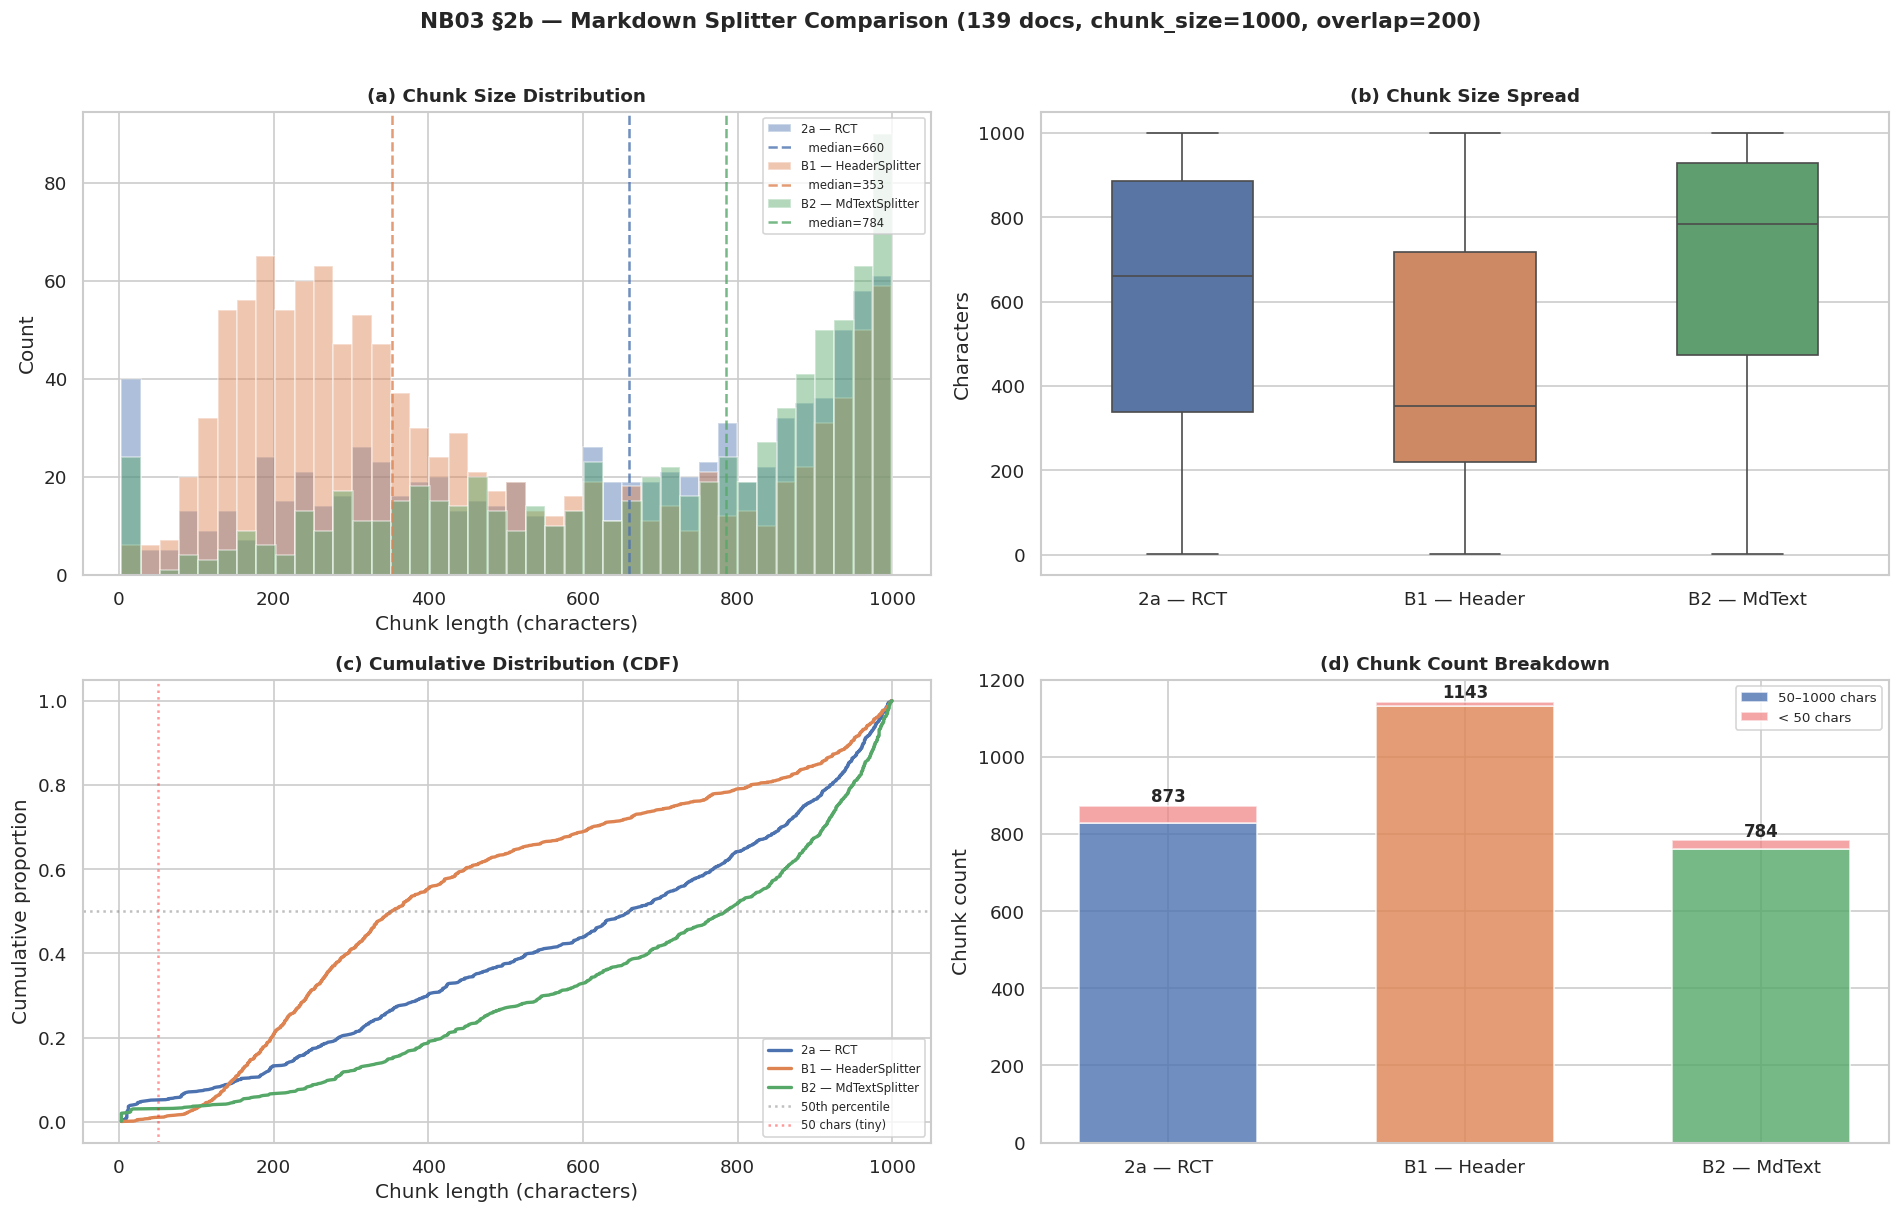

Figure saved → outputs/nb03_2b_md_splitter_comparison.png


In [25]:
# ── 2b. Visual comparison: chunk size distributions (2a vs B1 vs B2) ──

COLORS = {
    "2a — RCT": "#4C72B0",
    "B1 — HeaderSplitter": "#DD8452",
    "B2 — MdTextSplitter": "#55A868",
}

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# ── (a) Overlapping histograms ──
ax = axes[0, 0]
for label, lengths, color in [
    ("2a — RCT", md_lengths, COLORS["2a — RCT"]),
    ("B1 — HeaderSplitter", b1_lengths, COLORS["B1 — HeaderSplitter"]),
    ("B2 — MdTextSplitter", b2_lengths, COLORS["B2 — MdTextSplitter"]),
]:
    ax.hist(lengths, bins=40, alpha=0.45, label=label, color=color, edgecolor="white")
    ax.axvline(np.median(lengths), color=color, linestyle="--", alpha=0.8,
               label=f"  median={np.median(lengths):.0f}")
ax.set_xlabel("Chunk length (characters)")
ax.set_ylabel("Count")
ax.set_title("(a) Chunk Size Distribution", fontsize=11, fontweight="bold")
ax.legend(fontsize=7, loc="upper right")

# ── (b) Box plots ──
ax = axes[0, 1]
box_data = pd.DataFrame({
    "length": md_lengths + b1_lengths + b2_lengths,
    "strategy": (
        ["2a — RCT"] * len(md_lengths)
        + ["B1 — Header"] * len(b1_lengths)
        + ["B2 — MdText"] * len(b2_lengths)
    ),
})
sns.boxplot(
    data=box_data, x="strategy", y="length",
    palette=[COLORS["2a — RCT"], COLORS["B1 — HeaderSplitter"], COLORS["B2 — MdTextSplitter"]],
    ax=ax, width=0.5,
)
ax.set_title("(b) Chunk Size Spread", fontsize=11, fontweight="bold")
ax.set_ylabel("Characters")
ax.set_xlabel("")

# ── (c) Cumulative distribution (CDF) ──
ax = axes[1, 0]
for label, lengths, color in [
    ("2a — RCT", md_lengths, COLORS["2a — RCT"]),
    ("B1 — HeaderSplitter", b1_lengths, COLORS["B1 — HeaderSplitter"]),
    ("B2 — MdTextSplitter", b2_lengths, COLORS["B2 — MdTextSplitter"]),
]:
    sorted_l = np.sort(lengths)
    cdf = np.arange(1, len(sorted_l) + 1) / len(sorted_l)
    ax.plot(sorted_l, cdf, label=label, color=color, linewidth=2)
ax.axhline(0.5, color="gray", linestyle=":", alpha=0.5, label="50th percentile")
ax.axvline(50, color="red", linestyle=":", alpha=0.4, label="50 chars (tiny)")
ax.set_xlabel("Chunk length (characters)")
ax.set_ylabel("Cumulative proportion")
ax.set_title("(c) Cumulative Distribution (CDF)", fontsize=11, fontweight="bold")
ax.legend(fontsize=7)

# ── (d) Summary bar chart: chunk count + tiny/normal breakdown ──
ax = axes[1, 1]
labels = ["2a — RCT", "B1 — Header", "B2 — MdText"]
all_lens = [md_lengths, b1_lengths, b2_lengths]
tiny = [sum(1 for l in ls if l < 50) for ls in all_lens]
normal = [sum(1 for l in ls if 50 <= l <= 1000) for ls in all_lens]
oversized = [sum(1 for l in ls if l > 1000) for ls in all_lens]

x = np.arange(len(labels))
w = 0.6
bars_normal = ax.bar(x, normal, w, label="50–1000 chars", color=[COLORS[k] for k in COLORS], alpha=0.8)
bars_tiny = ax.bar(x, tiny, w, bottom=normal, label="< 50 chars", color="lightcoral", alpha=0.7)

# Annotate totals
for i, total in enumerate([len(ls) for ls in all_lens]):
    ax.text(i, total + 10, str(total), ha="center", fontweight="bold", fontsize=10)

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Chunk count")
ax.set_title("(d) Chunk Count Breakdown", fontsize=11, fontweight="bold")
ax.legend(fontsize=8)

plt.suptitle(
    "NB03 §2b — Markdown Splitter Comparison (139 docs, chunk_size=1000, overlap=200)",
    fontsize=13, fontweight="bold", y=1.01,
)
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / "nb03_2b_md_splitter_comparison.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"Figure saved → outputs/nb03_2b_md_splitter_comparison.png")

### 2c. JavaScript / MJS / CJS — Code-Aware Splitting

1. Use `RecursiveCharacterTextSplitter.from_language(Language.JS)` for syntax-aware separators.
2. Set `chunk_size=1500`, `chunk_overlap=200` (code needs more context per chunk).
3. Exclude barrel files (`index.js` that are pure re-exports) — detect by high export-to-line ratio.
4. Attach metadata: `source`, `zone` (core/map/extras), `content_type=javascript`.
5. Sample a few dense files (e.g., `utils.layers.js`, `utils.features.js`) and inspect chunk boundaries.

In [26]:
# ── 2c. JavaScript chunking with barrel file detection ──

js_splitter = RecursiveCharacterTextSplitter.from_language(
    Language.JS,
    chunk_size=CHUNK_PARAMS["javascript"]["chunk_size"],
    chunk_overlap=CHUNK_PARAMS["javascript"]["chunk_overlap"],
)


def is_barrel_file(filepath: Path, threshold: float = 0.6) -> bool:
    """Detect barrel files (index.js with high export/import-to-line ratio)."""
    try:
        text = filepath.read_text(encoding="utf-8")
    except (OSError, UnicodeDecodeError):
        return False
    lines = [l.strip() for l in text.splitlines() if l.strip() and not l.strip().startswith("//")]
    if len(lines) < 2:
        return True  # nearly empty file
    export_lines = sum(1 for l in lines if l.startswith("export ") or l.startswith("module.exports"))
    import_lines = sum(1 for l in lines if l.startswith("import ") or "require(" in l)
    return (export_lines + import_lines) / len(lines) >= threshold


def chunk_js_files(file_records: list) -> list[dict]:
    """Chunk JavaScript files using Language.JS-aware splitter."""
    chunks = []
    skipped_barrels = 0
    for rec in file_records:
        # Skip barrel files even if they weren't classified as such
        if rec.path.name == "index.js" and is_barrel_file(rec.path):
            skipped_barrels += 1
            continue

        try:
            text = rec.path.read_text(encoding="utf-8")
        except (OSError, UnicodeDecodeError):
            continue

        rel_path = str(rec.path.relative_to(KDK_DIR))
        docs = js_splitter.create_documents(
            texts=[text],
            metadatas=[{"source": rel_path}],
        )

        for i, doc in enumerate(docs):
            content = doc.page_content.strip()
            if not content:
                continue
            chunks.append({
                "text": content,
                "metadata": {
                    "source": rel_path,
                    "content_type": "javascript",
                    "zone": rec.zone,
                    "chunk_index": i,
                    "char_count": len(content),
                },
            })

    print(f"  Barrel files skipped: {skipped_barrels}")
    return chunks


js_chunks = chunk_js_files(files_to_chunk.get("code_js", []))
js_lengths = [c["metadata"]["char_count"] for c in js_chunks]

print(f"JavaScript chunks: {len(js_chunks)}")
if js_lengths:
    print(f"  Mean size: {np.mean(js_lengths):.0f} chars")
    print(f"  Median:    {np.median(js_lengths):.0f} chars")
    print(f"  Min/Max:   {min(js_lengths)} / {max(js_lengths)} chars")
    print(f"  < 50 chars: {sum(1 for l in js_lengths if l < 50)}")
    print(f"  > 1500 chars: {sum(1 for l in js_lengths if l > 1500)}")

  Barrel files skipped: 0
JavaScript chunks: 1608
  Mean size: 1010 chars
  Median:    1173 chars
  Min/Max:   1 / 1500 chars
  < 50 chars: 21
  > 1500 chars: 0


---
## 3. Unified Chunk Assembly and Statistics

### Steps

1. Merge all chunks from sections 2a–2e into a single list with normalized metadata schema:
   - Required fields: `text`, `source`, `content_type`, `zone`.
   - Optional fields: `doc_title`, `h1`, `h2`, `h3`, `section_title`, `block_type`, `json_type`.
2. Deduplicate: check for near-identical chunks (e.g., shared code across projects).
3. Global statistics table:
   - Per content_type: chunk count, mean/median/max size (chars), estimated tokens.
   - Total chunk count and token budget.
4. Size distribution histogram (overlaid by content_type), analogous to NB02 §3.
5. Comparison with NB02: how many more chunks does the mixed index add vs docs-only?

---
## 4. Embedding and Qdrant Ingestion

### Steps

1. Load `nomic-ai/nomic-embed-text-v1.5` (same model as NB02 for comparability).
2. Embed all chunks in batches. Use `search_document:` prefix for nomic embedding.
3. Create Qdrant collection `nb03_multi_type` and ingest all points.
4. Verify point count matches chunk count.
5. Also re-ingest NB02's best collection (LangChain RCT, docs-only) as `nb03_docs_baseline` for direct comparison.

---
## 5. Evaluation (Extended Question Set)

### 5a. Extend the question set

1. Keep NB02's 25 questions (for continuity).
2. Add new questions that require code/config knowledge:
   - Code questions: "What parameters does `createFeaturesService` accept?", "How is the catalog service hook chain structured?"
   - Vue questions: "Which component handles the timeline display?", "What props does KLocationMap accept?"
   - JSON/config questions: "What fields are required in a message creation schema?", "What is the French translation for 'KActivity.SEARCH'?"
   - Cross-type questions: "How do I add a new layer type from service definition to UI component?"
3. Target: ~40 questions total, balanced across content types and categories.

### 5b. Retrieval evaluation

1. For each question, retrieve top-K from both collections (`nb03_multi_type` and `nb03_docs_baseline`).
2. LLM-as-Judge evaluation (same protocol as NB02).
3. Compute Hit@1, Hit@5, Hit@20, MRR per strategy.

### 5c. Content-type contribution analysis

1. For each question, log which `content_type` the first relevant chunk belongs to.
2. Build a confusion-style matrix: question category vs content_type of best chunk.
3. Identify which content types contribute most to retrieval quality.

---
## 6. Analysis and Conclusions

### Visualizations

1. Radar chart: multi-type index vs docs-only baseline (Hit@1, Hit@5, Hit@20, MRR).
2. Per-category bar chart: which question categories improve most with code/config chunks.
3. Content-type contribution heatmap: which content types answer which question categories.
4. Wilcoxon signed-rank test: multi-type vs docs-only on reciprocal ranks.

### Decisions for Phase 3

1. Finalize the chunking pipeline (splitter configs, metadata schema) to carry forward.
2. Identify content types with low retrieval contribution (candidates for exclusion or re-chunking).
3. Document the final question set for embedding model comparison (Phase 3).
4. Record token cost for this notebook via `TrackedClient`.